# 27_01 RUL 기반 고장 임박 문제

In [230]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 라이브러리 임포트와 첫 불러오기
- 내내 다룰 데이터를 컴퓨터로 불러와 첫인사를 나누는 단계
- pandas를 불러오고 cmapss_fd001_sample.csv를 표로 읽어 첫 모습 확인

### 불러오기 코드
pandas를 pd로 부르고 read_csv로 파일을 df라는 표에 담기

In [231]:
# 코드
df = pd.read_csv('27_cmapss_fd001_sample.csv')

### 첫 모습 확인
head로 첫 5행을, shape로 행과 열 개수를 확인

In [232]:
# 코드
df.shape
df.head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142


### 데이터 크기 점검
shape로 전체 행과 열의 개수를 다시 확인해 규모 감을 잡기

In [233]:
# 코드
df.shape

(3614, 9)

### 컬럼 이름 확인
분석 전 데이터가 어떻게 생겼는지 살펴보는 일은 길 떠나기 전 지도 확인

In [234]:
# 코드
df.columns.to_list()

['unit_id',
 'cycle',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_11',
 'sensor_15',
 'RUL']

### 자료형과 결측 요약
info는 각 컬럼의 자료형과 값 개수를 요약 — 결측 단서까지 한눈에

In [235]:
# 코드
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    3614 non-null   int64  
 1   cycle      3614 non-null   int64  
 2   sensor_2   3614 non-null   float64
 3   sensor_3   3614 non-null   float64
 4   sensor_4   3614 non-null   float64
 5   sensor_7   3614 non-null   float64
 6   sensor_11  3614 non-null   float64
 7   sensor_15  3614 non-null   float64
 8   RUL        3614 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 254.2 KB


### 기초 통계 살펴보기
describe는 숫자 컬럼의 평균·최소·최대 같은 기초 통계 한눈에

In [236]:
# 코드
print(df.describe())

           unit_id        cycle     sensor_2     sensor_3     sensor_4  \
count  3614.000000  3614.000000  3614.000000  3614.000000  3614.000000   
mean     10.480077    91.842833   642.716319  1588.630193  1408.919402   
std       5.822356    53.855330     0.716776     4.817425     9.056095   
min       1.000000     1.000000   640.384000  1572.759000  1379.889000   
25%       5.000000    46.000000   642.179250  1585.314000  1402.384250   
50%      10.000000    91.000000   642.688000  1588.647500  1408.515500   
75%      16.000000   136.000000   643.237000  1591.869250  1415.269000   
max      20.000000   215.000000   645.006000  1604.662000  1437.818000   

          sensor_7    sensor_11    sensor_15          RUL  
count  3614.000000  3614.000000  3614.000000  3614.000000  
mean    553.124533    47.559457     8.473617    90.842833  
std       0.832421     0.366593     0.067264    53.855330  
min     550.291000    46.447000     8.285000     0.000000  
25%     552.530250    47.285250  

### 마지막 행 확인
tail로 마지막 5행을 보고 데이터가 끝까지 잘 들어왔는지 확인

In [237]:
# 코드
print(df.tail())

      unit_id  cycle  sensor_2  sensor_3  sensor_4  sensor_7  sensor_11  \
3609       20    175   643.919  1592.113  1429.256   552.014     47.574   
3610       20    176   643.451  1595.543  1415.133   551.931     47.743   
3611       20    177   643.936  1599.696  1423.106   551.428     48.458   
3612       20    178   644.133  1591.473  1422.361   551.418     48.173   
3613       20    179   643.577  1591.796  1424.141   551.387     47.721   

      sensor_15  RUL  
3609      8.533    4  
3610      8.576    3  
3611      8.570    2  
3612      8.611    1  
3613      8.594    0  


### 설비 대수 세기
nunique는 서로 다른 값의 개수 — unit_id에 적용해 설비 대수 확인

In [238]:
# 코드
print(df['unit_id'].nunique())

20


## 결측치와 센서 범위 점검
- 빠진 값과 센서마다 값 크기 차이 — 분석 전 빈틈 점검부터
- 컬럼별 결측치 개수를 세고 센서값 범위를 비교
- 좋은 분석은 데이터의 빈틈을 먼저 점검하는 데서 시작


### 결측치 세기
isna와 sum을 이어 쓰면 컬럼별 결측치 개수 한눈에

In [239]:
# 코드
df.isna().sum()

unit_id      0
cycle        0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_7     0
sensor_11    0
sensor_15    0
RUL          0
dtype: int64

### 한 센서 분포 보기
특정 센서 하나에 describe를 적용해 값의 분포를 자세히 보기

In [240]:
# 코드
df['sensor_3'].describe()

count    3614.000000
mean     1588.630193
std         4.817425
min      1572.759000
25%      1585.314000
50%      1588.647500
75%      1591.869250
max      1604.662000
Name: sensor_3, dtype: float64

## 한 설비의 일생 따라가기
- 1번 엔진 하나만 떼어 내어 처음부터 고장까지 행을 따라 읽기
- 설비 한 대만 골라 cycle 순서로 RUL과 센서 변화 관찰
- 전체가 아니라 1번 엔진 하나에 집중

### 여러 센서 평균 비교
센서 여러 개의 평균을 한 번에 비교

In [241]:
# 코드
df[['sensor_2',
'sensor_3',
'sensor_4',
'sensor_7',
'sensor_11',
'sensor_15']].mean()


sensor_2      642.716319
sensor_3     1588.630193
sensor_4     1408.919402
sensor_7      553.124533
sensor_11      47.559457
sensor_15       8.473617
dtype: float64

### 한 설비만 골라내기
unit_id가 1인 행만 골라 unit1에 담고 행 수 확인

In [242]:
# 코드
unit1 = df[df['unit_id'] == 1]
len(unit1)

147

### 시작과 끝의 RUL 비교
이 설비의 시작 부분과 끝부분 RUL을 한눈에 비교

In [243]:
# 코드
print(unit1['RUL'].head())
print(unit1['RUL'].tail())

0    146
1    145
2    144
3    143
4    142
Name: RUL, dtype: int64
142    4
143    3
144    2
145    1
146    0
Name: RUL, dtype: int64


### RUL 변화 그래프 그리기
cycle에 따른 RUL 변화를 선 그래프로 그려 우하향 직선 확인

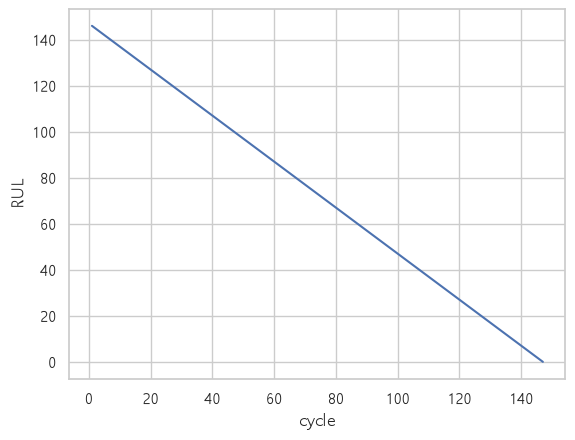

In [244]:
# 코드
plt.plot(unit1['cycle'], unit1['RUL'])
plt.xlabel("cycle")
plt.ylabel("RUL")
plt.show()

## 두 설비의 수명 비교
- 설비끼리는 cycle만으로 비교 불가 — 두 설비를 나란히 두고 직접 확인
- 두 설비의 최대 cycle 비교 + 같은 cycle에서 상태 차이
- 설비마다 고장까지 버티는 cycle 수가 다름을 직접 확인

### 설비별 수명 길이 구하기
groupby로 설비별 최대 cycle(=수명 길이)을 구하고 정렬


In [245]:
# 코드
# 설비별 가장 큰 cycle 수명 길이
life = df.groupby('unit_id')['cycle'].max()

# 오래 산 설비부터 일찍 고장난 설비까지 보기
life.sort_values()


unit_id
1     147
12    149
9     161
10    163
15    164
13    168
18    172
7     173
14    177
6     177
17    177
20    179
11    187
3     197
8     198
5     198
2     202
4     205
19    205
16    215
Name: cycle, dtype: int64

### 같은 cycle에서 RUL 비교
두 설비의 같은 50 cycle 시점을 각각 골라 RUL 비교

In [250]:
# 1번 엔진의 50 cycle 시점
print(df[(df['unit_id'] == 1) & (df['cycle'] == 50)][['RUL', 'cycle']])
# 2번 엔진의 50 cycle 시점
print(df[(df['unit_id'] == 2) & (df['cycle'] == 50)][['RUL', 'cycle']])

    RUL  cycle
49   97     50
     RUL  cycle
196  152     50


## 비교에서 얻는 교훈
- 같은 cycle이라도 설비마다 RUL이 다름
- cycle만으로는 설비끼리 직접 비교할 수 없음